In [8]:
from pathlib import Path

import numpy  as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

from scipy.interpolate import interp1d

from nbtools import auto_plot_style

%matplotlib inline
auto_plot_style()

In [9]:
def draw_pcolina():
    points = np.array([
        [-16.,    0.],
        [-16., - 10.],
        [-136, -120.],
        [ 136, -120.],
        [ 16., - 10.],
        [ 16.,    0.],
    ])
    
    ticks      = np.arange(-120, 1, 20)
    ticklabels = list(map(str, -ticks))
    plt.yticks(ticks, ticklabels)
    p = Polygon(points, closed=True, facecolor="None", edgecolor="r")
    plt.gca().add_patch(p)

def draw_colina():
    points = np.array([
        [-32.,    0.],
        [-32., - 10.],
        [-272, -240.],
        [ 272, -240.],
        [ 32., - 10.],
        [ 32.,    0.],
    ])
    
    ticks      = np.arange(-240, 1, 40)
    ticklabels = list(map(str, -ticks))
    plt.yticks(ticks, ticklabels)
    p = Polygon(points, closed=True, facecolor="None", edgecolor="r")
    plt.gca().add_patch(p)

In [10]:
def find_line(anode, lines, x):
    i = np.argmin(np.abs(anode.r.values - np.abs(x)))
    return lines.loc[lines.line == anode.line.iloc[i]]

def interpolate(line, z):
    return interp1d(line.z, line.r, kind="linear", bounds_error=False, fill_value="extrapolate")(z)

# pCOLINA

In [59]:
filename = "/home/gonzalo/data/COLINA/pCOLINA_triangular_efield_ring_degrad_4.5_form_factor_1.txt"
filename = "/home/gonzalo/data/COLINA/pCOLINA_triangular_efield_ring_degrad_3.75_form_factor_1.txt"

lines = np.loadtxt(filename, comments="%")[:, :3]
lines = pd.DataFrame(lines*1e3, columns="r z line".split())
lines = lines.astype(dict(line=int))
lines = lines.groupby("line").filter(lambda df: df.z.min() < -119)
lines = lines.groupby("line").filter(lambda df: df.z.max() >   -1)
lines

,r,z,line
8367,115.688859,-1.200000e+02,27000
8368,115.691621,-1.199271e+02,27000
8369,115.697737,-1.197828e+02,27000
8370,115.699312,-1.197487e+02,27000
8371,115.703740,-1.196580e+02,27000
...,...,...,...
226956,0.065849,-2.892701e-01,183000
226957,0.065720,-1.827661e-01,183000
226958,0.065592,-7.585265e-02,183000
226959,0.065562,-5.022142e-02,183000


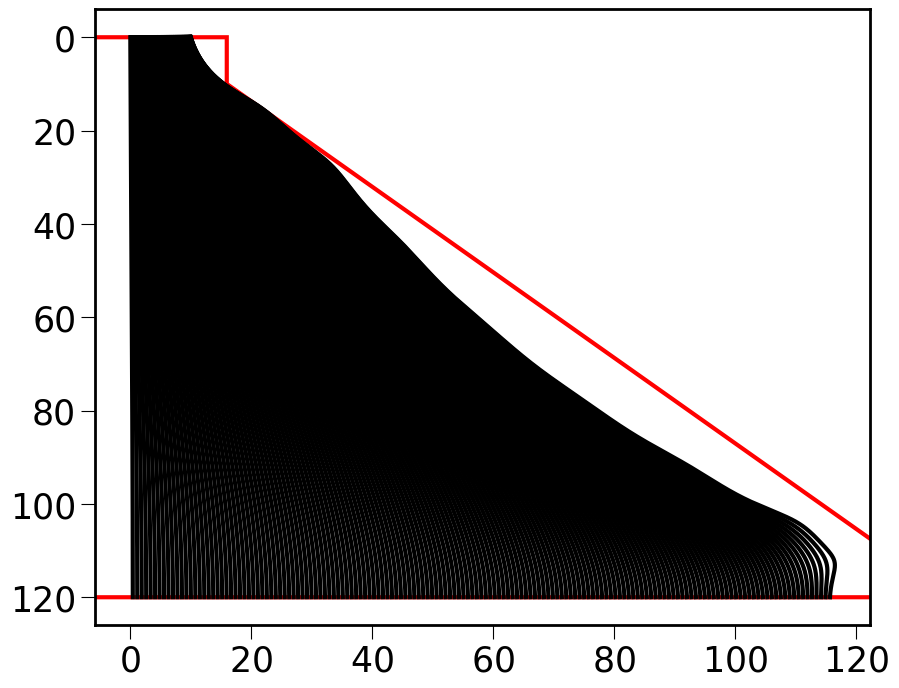

In [60]:
for _, line in lines.groupby("line"):
    plt.plot(line.r, line.z, "k-")

draw_pcolina()

# 1 Sigma

In [66]:
reco = pd.DataFrame([[-17.1391518 ,  -1.26121149,  -1.26121149],
                     [-15.32894212,  -3.50614061,  -0.05325391],
                     [-14.36728003,  -2.72379925,   1.34571251],
                     [-13.44477218,  -2.4464608 ,   2.03306325],
                     [-12.47527802,  -2.63772554,   2.7700798 ],
                     [-11.47804947,  -3.36877768,   3.13846938],
                     [-10.49651759,  -3.56070313,   3.90660796],
                     [ -9.50458481,  -3.77708473,   4.14902474],
                     [ -8.4870552 ,  -3.61565777,   4.43851141],
                     [ -7.49695373,  -3.90689616,   4.44046688],
                     [ -6.50115987,  -3.98817107,   4.49792593],
                     [ -5.50625221,  -4.10988092,   4.74604945],
                     [ -4.5043262 ,  -4.67696396,   5.33731622],
                     [ -3.50226384,  -4.60673305,   5.35947067],
                     [ -2.50537871,  -5.01403285,   5.6297858 ],
                     [ -1.49440536,  -5.01574428,   5.74067908],
                     [ -0.50103838,  -4.9420004 ,   6.37869316],
                     [  0.49385115,  -5.40353042,   6.15844956],
                     [  1.49659087,  -5.19166779,   5.64719581],
                     [  2.49186029,  -4.45976754,   5.8631252 ],
                     [  3.49831263,  -4.69776866,   5.37173521],
                     [  4.49211287,  -4.64472301,   4.85090248],
                     [  5.4984623 ,  -4.5108319 ,   4.64236869],
                     [  6.49515119,  -4.2158137 ,   5.07528149],
                     [  7.5026601 ,  -4.1501357 ,   4.72245804],
                     [  8.49457777,  -3.7973723 ,   4.68222896],
                     [  9.4970227 ,  -3.70647237,   4.55020777],
                     [ 10.5088403 ,  -3.40680472,   4.22720325],
                     [ 11.4943439 ,  -3.18295537,   3.72216213],
                     [ 12.47915547,  -2.41988961,   3.67041061],
                     [ 13.45884235,  -1.80467411,   2.98830892],
                     [ 14.45756016,  -1.219269  ,   2.65605129],
                     [ 15.38871433,  -0.32219432,   3.79737813],
                     [ 16.39732966,   0.44956398,   3.98175942]], columns="anode anode_lower anode_upper".split())

reco.loc[:, "anode_lower"] = reco.anode + reco.anode_lower
reco.loc[:, "anode_upper"] = reco.anode + reco.anode_upper
reco = reco.iloc[1:-1]
reco

,anode,anode_lower,anode_upper
1,-15.328942,-18.835083,-15.382196
2,-14.367280,-17.091079,-13.021568
3,-13.444772,-15.891233,-11.411709
4,-12.475278,-15.113004,-9.705198
5,-11.478049,-14.846827,-8.339580
6,-10.496518,-14.057221,-6.589910
7,-9.504585,-13.281670,-5.355560
8,-8.487055,-12.102713,-4.048544
9,-7.496954,-11.403850,-3.056487
10,-6.501160,-10.489331,-2.003234


# 2 Sigma

In [76]:
reco = pd.DataFrame([[-17.1391518 ,  -1.26121149,  -1.26121149],
                     [-15.32894212,  -6.59165412,   0.61582845],
                     [-14.36728003,  -6.93993912,   2.47597324],
                     [-13.44477218,  -6.77894649,   3.31620142],
                     [-12.47527802,  -6.71056738,   4.26918414],
                     [-11.47804947,  -7.7551472 ,   5.12860654],
                     [-10.49651759,  -8.89241744,   5.72974133],
                     [ -9.50458481,  -9.33143488,   6.268997  ],
                     [ -8.4870552 ,  -9.09882864,   7.07604927],
                     [ -7.49695373,  -9.94859331,   7.54087881],
                     [ -6.50115987,  -9.33739849,   7.88183468],
                     [ -5.50625221, -10.59292632,   8.62964841],
                     [ -4.5043262 , -11.51443223,   9.16722756],
                     [ -3.50226384, -11.85393341,   9.47917867],
                     [ -2.50537871, -11.6466235 ,  10.47832648],
                     [ -1.49440536, -12.34074817,  11.30598277],
                     [ -0.50103838, -10.97320098,  11.77353615],
                     [  0.49385115, -12.14207801,  12.37786152],
                     [  1.49659087, -10.66105777,  11.58471799],
                     [  2.49186029,  -9.55019139,  12.0721386 ],
                     [  3.49831263,  -9.3739716 ,  12.23713804],
                     [  4.49211287,  -8.79977544,  11.74319793],
                     [  5.4984623 ,  -8.33166885,  11.23804082],
                     [  6.49515119,  -7.67359029,  10.06915446],
                     [  7.5026601 ,  -7.70982903,  10.36280044],
                     [  8.49457777,  -6.89794685,  10.32361952],
                     [  9.4970227 ,  -6.1674372 ,   9.08396667],
                     [ 10.5088403 ,  -5.4503437 ,   8.71264105],
                     [ 11.4943439 ,  -5.04943858,   7.854696  ],
                     [ 12.47915547,  -4.2180989 ,   7.978536  ],
                     [ 13.45884235,  -3.11666103,   7.04218681],
                     [ 14.45756016,  -2.65442579,   6.4534442 ],
                     [ 15.38871433,  -1.39626755,   6.45066342],
                     [ 16.39732966,  -0.79416655,   7.28010532]], columns="anode anode_lower anode_upper".split())

reco.loc[:, "anode_lower"] = reco.anode + reco.anode_lower
reco.loc[:, "anode_upper"] = reco.anode + reco.anode_upper
reco = reco.iloc[1:-1]
reco

,anode,anode_lower,anode_upper
1,-15.328942,-21.920596,-14.713114
2,-14.367280,-21.307219,-11.891307
3,-13.444772,-20.223719,-10.128571
4,-12.475278,-19.185845,-8.206094
5,-11.478049,-19.233197,-6.349443
6,-10.496518,-19.388935,-4.766776
7,-9.504585,-18.836020,-3.235588
8,-8.487055,-17.585884,-1.411006
9,-7.496954,-17.445547,0.043925
10,-6.501160,-15.838558,1.380675


[ -0.50103838 -11.47423936  11.27249777]
[ 8.49457777  1.59663092 18.81819729]


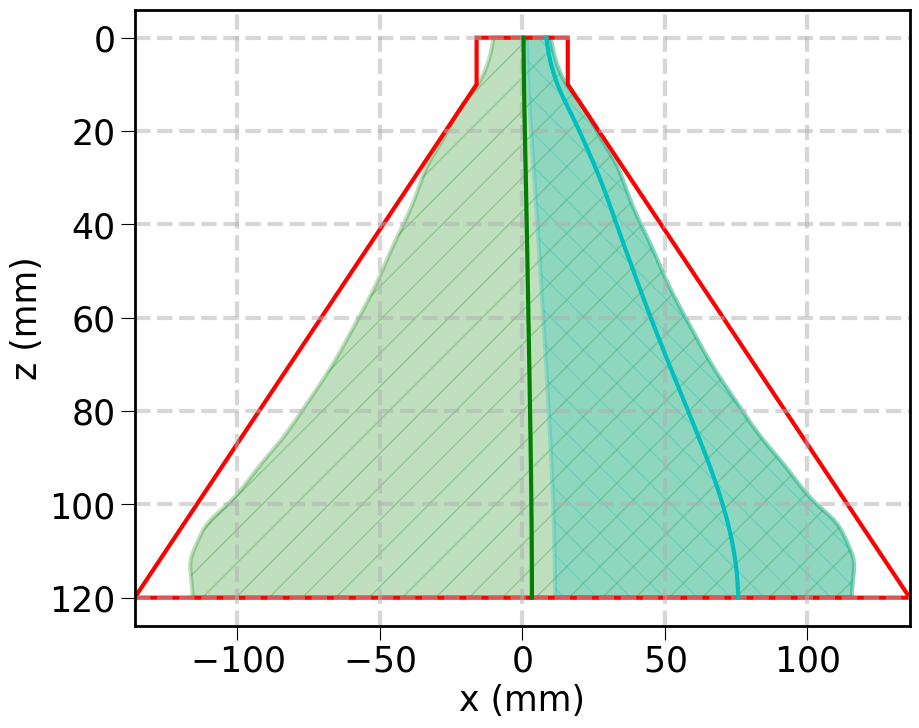

In [78]:
z = np.linspace(-120, 0, 101)


row = reco.loc[16]
print(row.values)

line_lower  = find_line(anode, lines, np.abs(row.anode_lower))
line_center = find_line(anode, lines, np.abs(row.anode      ))
line_upper  = find_line(anode, lines, np.abs(row.anode_upper))

xlower = np.sign(row.anode_lower) * interpolate(line_lower, z)
xupper = np.sign(row.anode_upper) * interpolate(line_upper, z)

plt.plot(interpolate(line_center, z), z, "g-")
plt.fill_betweenx(z, xlower, xupper, hatch="/", color="g", alpha=0.25)
plt.xlabel("x (mm)")
plt.ylabel("z (mm)")


row = reco.loc[25]
print(row.values)

line_lower  = find_line(anode, lines, np.abs(row.anode_lower))
line_center = find_line(anode, lines, np.abs(row.anode      ))
line_upper  = find_line(anode, lines, np.abs(row.anode_upper))

xlower = np.sign(row.anode_lower) * interpolate(line_lower, z)
xupper = np.sign(row.anode_upper) * interpolate(line_upper, z)

plt.plot(interpolate(line_center, z), z, "c-")
plt.fill_betweenx(z, xlower, xupper, hatch="\\", color="c", alpha=0.25)
plt.xlabel("x (mm)")
plt.ylabel("z (mm)")

plt.xlim(-136, 136)

draw_cone()
plt.grid()

# COLINA

In [41]:
filename = "/home/gonzalo/data/COLINA/comsol/COLINA_triangular_efield_ring_degrad_4_form_factor_1.txt"
lines = np.loadtxt(filename, comments="%")[:, :3]
lines = pd.DataFrame(lines*1e3, columns="r z line".split())
lines = lines.astype(dict(line=int))
lines = lines.groupby("line").filter(lambda df: df.z.min() < -239)
lines = lines.groupby("line").filter(lambda df: df.z.max() >   -1)
anode = lines.groupby("line").last().reset_index()
lines

,r,z,line
75,264.611413,-2.400000e+02,2000
76,264.594744,-2.398778e+02,2000
77,264.557906,-2.396352e+02,2000
78,264.528338,-2.394616e+02,2000
79,264.492332,-2.392694e+02,2000
...,...,...,...
167847,0.219125,-6.503254e-01,91000
167848,0.218956,-4.494702e-01,91000
167849,0.218823,-2.838725e-01,91000
167850,0.218669,-8.546756e-02,91000


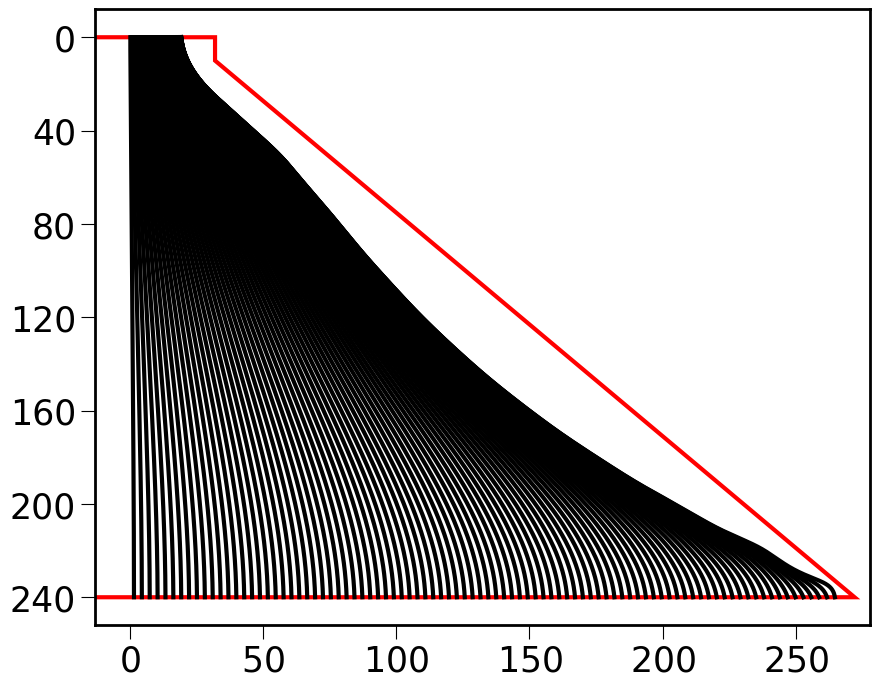

In [42]:
for _, line in lines.groupby("line"):
    plt.plot(line.r, line.z, "k-")

draw_colina()

In [43]:
anode = lines.groupby("line").last().reset_index()

In [44]:
path = Path("/home/gonzalo/data/COLINA/mc/colina/")
wires5  = pd.read_hdf(path / "dsipms_2mm_reco_summary.h5")
wires2  = pd.read_hdf(path / "pitch_2mm_diam_2um_reco_summary.h5")

In [45]:
def percentiles(df):
    lower  = np.percentile(df.dx, 15.86)
    upper  = np.percentile(df.dx, 84.13)
    sigma1 = (upper - lower)/2
    lower = np.percentile(df.dx,  2.50)
    upper = np.percentile(df.dx, 97.50)
    sigma2 = (upper - lower)/2
    return pd.Series(dict(sigma1=sigma1, sigma2=sigma2))

def error(df, rmax, n):
    rbins = np.linspace(0, rmax, n+1)
    return (df.assign(rbin=np.digitize(df.r0, rbins)-1)
              .groupby("rbin")
              .apply(percentiles)
              .reset_index()
              .assign(r = lambda df: (df.rbin + 0.5) * np.diff(rbins)[0])
           )

In [46]:
wires5_e = error(wires5, 32, 25)
wires2_e = error(wires2, 32, 25)

/tmp/ipykernel_3627112/1319424841.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(percentiles)
/tmp/ipykernel_3627112/1319424841.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(percentiles)


(-5.0, 5.0)

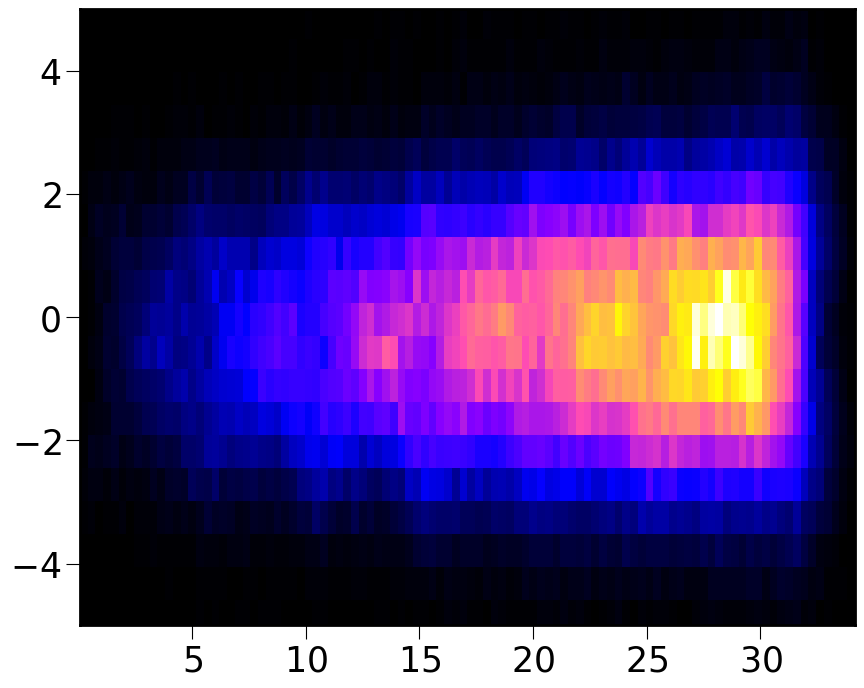

In [49]:
df = wires5

plt.hist2d(df.r0, df.dy, 100);
plt.ylim(-5, 5)

[1.         1.43345925 2.68417323 1.92      ]
[ 8.          1.56826604  2.76425519 10.88      ]
[14.          1.5267558   3.07287187 18.56      ]


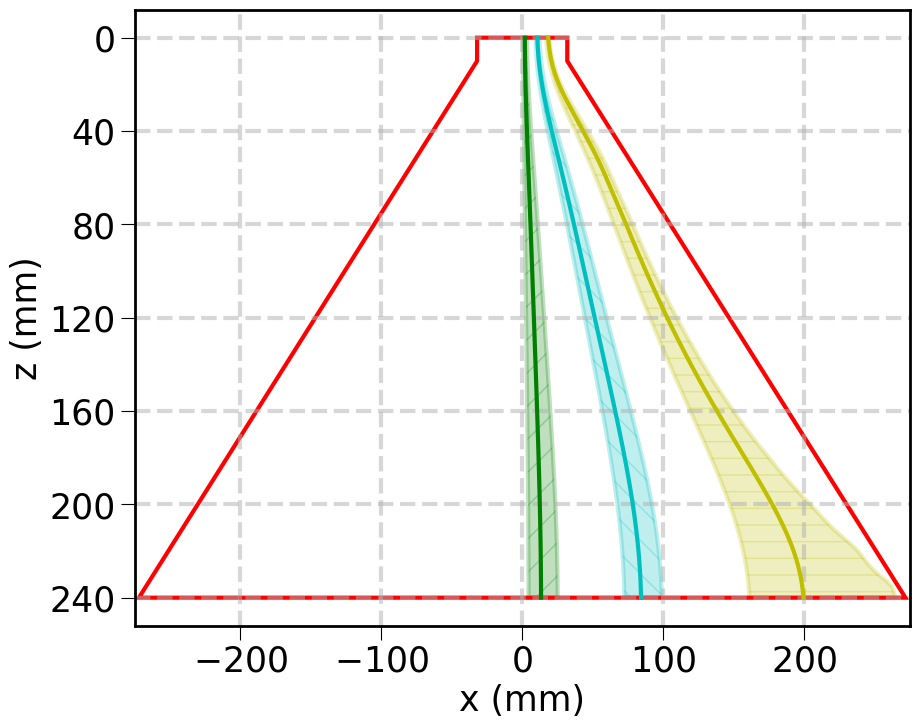

In [50]:
z = np.linspace(-240, 0, 101)
df = wires5_e

row = df.iloc[1]
print(row.values)

line_lower  = find_line(anode, lines, row.r - row.sigma1)
line_center = find_line(anode, lines, row.r             )
line_upper  = find_line(anode, lines, row.r + row.sigma1)

xlower = interpolate(line_lower, z)
xupper = interpolate(line_upper, z)

plt.plot(interpolate(line_center, z), z, "g-")
plt.fill_betweenx(z, xlower, xupper, hatch="/", color="g", alpha=0.25)
plt.xlabel("x (mm)")
plt.ylabel("z (mm)")


row = df.loc[8]
print(row.values)

line_lower  = find_line(anode, lines, row.r - row.sigma1)
line_center = find_line(anode, lines, row.r             )
line_upper  = find_line(anode, lines, row.r + row.sigma1)

xlower = interpolate(line_lower, z)
xupper = interpolate(line_upper, z)

plt.plot(interpolate(line_center, z), z, "c-")
plt.fill_betweenx(z, xlower, xupper, hatch="\\", color="c", alpha=0.25)
plt.xlabel("x (mm)")
plt.ylabel("z (mm)")

row = df.loc[14]
print(row.values)

line_lower  = find_line(anode, lines, row.r - row.sigma1)
line_center = find_line(anode, lines, row.r             )
line_upper  = find_line(anode, lines, row.r + row.sigma1)

xlower = interpolate(line_lower, z)
xupper = interpolate(line_upper, z)

plt.plot(interpolate(line_center, z), z, "y-")
plt.fill_betweenx(z, xlower, xupper, hatch="-", color="y", alpha=0.25)
plt.xlabel("x (mm)")
plt.ylabel("z (mm)")

plt.xlim(-275, 275)

draw_colina()
plt.grid()